# Case Studies in HPC Homework 2 - GMRES Method
## Notebook for part (2) - Givens Rotations


In [1]:
#imports

import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
from scipy.io import mmread
import os

## Function which generates the next column for the H matrix and the next entry for the Krylov basis, slight changes since we fix H size in this version

In [2]:
def VH_update(H, V, A, j):
    w = A @ V[:, j]

    for i in range(j + 1):
        H[i, j] = V[:, i] @ w
        w = w - H[i, j] * V[:, i]

    H[j + 1, j] = np.linalg.norm(w)

    if H[j + 1, j] > 0:
        V[:, j + 1] = w / H[j + 1, j]
        return H, V, 0
    else:
        print('Orthogonal basis complete')
        return H, V, 1

## Function which generates the Givens rotation entries for a given iteration

In [3]:
def GivGetter(a,b):
    if b == 0:
        return 1.0, 0.0

    r = np.hypot(a,b)
    c = a/r
    s = b/r

    return c, s

## Function which applies the Givens Rotation

In [4]:
def GivRot(c,s,a,b):
    return c*a + s*b, - s*a + c* b

## Function for bacwards substitution

In [5]:
def BackSub(R, g):
    n = R.shape[1]
    y = np.zeros(n)
    for i in range(n - 1, -1, -1):
        y[i] = (g[i] - R[i, i+1:n] @ y[i+1:n]) / R[i, i]
    return y

## Function which applies a simple GMRES iteration method


In [6]:
def GMRESgivrot(A, b, x0, tol, mx):
    #Creating the first residual from the guess vector
    r0 = b - A @ x0
    res0 = np.linalg.norm(A @ x0 - b)
    #Checking if the first residual is good enough for the tolerance
    if res0 < tol:
        return x0
    #Creating an array of residuals for plotting later
    residuals = [res0]

    #Defining the array to hold the orthogonal basis of the kryloc subspace
    n = len(b)
    V = np.zeros((n, mx +1))

    #Defining the array to store the cosines and sines for Givens
    cs = np.zeros(mx)
    sn = np.zeros(mx)
    g = np.zeros(mx+1)
    g[0] = res0

    #Appending the first basis vectornto the basis
    V[:,0] = r0/res0

    #Here we do the initial Hessenberg construction
    H = np.zeros((mx + 1, mx))
    H[0,0] = V[:,0] @ (A @ V[:,0])
    vhat2 = A @ V[:,0] - H[0,0] * V[:,0]
    H[1,0] = np.linalg.norm(vhat2)
    if H[1,0] > 0:
        V[:,1] = vhat2 / H[1,0]
    else:
        print('Process ended as orthogonal basis complete')
        return x0, residuals

    # First Givens rotation
    cs[0], sn[0] = GivGetter(H[0, 0], H[1, 0])
    H[0, 0], H[1, 0] = GivRot(cs[0], sn[0], H[0, 0], H[1, 0])
    g[0], g[1] = GivRot(cs[0], sn[0], g[0], g[1])

    res = abs(g[1])
    
    #storing the first new residual
    residuals.append(res)

    #counter to enforce a maximum of iterations on the while loop
    counter = 1

    #while loop which repeats the above process until the tolerance is reached
    while(res >= tol):

        #break if maximum counter is hit
        if counter == mx:
            print('Process ended as iteration ceiling enforced')
            break 

        #Generates the new H,V matrices using the Schutz algorithm 
        H, V, check = VH_update(H, V, A, counter)  

        #break for the hjj = 0 check in the update function
        if check == 1:
            print('Process ended as orthogonal basis complete')
            break

        #Apply all previous Givens rotations to the new column of H
        for i in range(counter):
            H[i, counter], H[i + 1, counter] = GivRot(cs[i], sn[i], H[i, counter], H[i + 1, counter])

        #COmpute the newest Givens rotation
        cs[counter], sn[counter] = GivGetter(H[counter, counter], H[counter + 1, counter])
        H[counter, counter], H[counter + 1, counter] = GivRot(cs[counter], sn[counter], H[counter, counter], H[counter+ 1, counter])

        #Apply the rotation to the rhs ray
        g[counter], g[counter + 1] = GivRot(cs[counter], sn[counter], g[counter], g[counter + 1])

        #calculate the residual norm from the most recent g value
        res = abs(g[counter + 1])
        residuals.append(res)

        counter +=1
         

    if(res <= tol):
        print('Process ended as tolerance reached')


    #recovering x form y
    R = H[:counter, :counter]
    y = BackSub(R, g[:counter])
    xfinal = x0 + V[:, :counter] @ y
        
    #Returning the final vector and the array of residuals
    return xfinal, residuals 

# Testing the function
## Small Matrix

Opening the matrix file

In [7]:
A = mmread("cdde6.mtx")

Creating a b vector for the solver

In [8]:
n, m = A.shape
b = np.ones(n)
x0= np.zeros(n)
tol = 0.000000000001
mx = 500
print(n)

961


Solving the system with our GMRES

In [9]:
xfinals, residuals = GMRESgivrot(A,b, x0, tol, mx)

Process ended as tolerance reached


Plotting the residuals

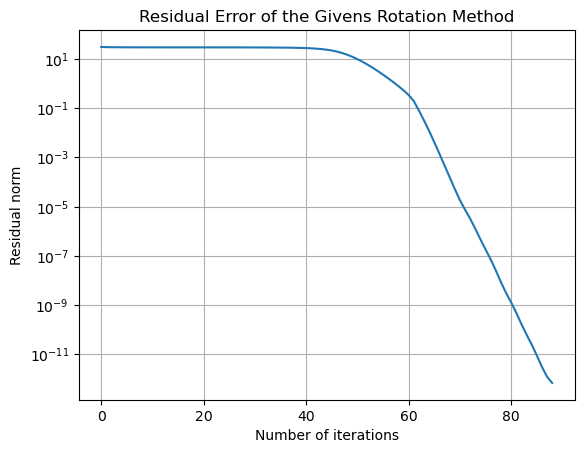

In [10]:
plt.plot(residuals)
plt.grid()
plt.xlabel('Number of iterations')
plt.ylabel('Residual norm')
plt.yscale("log")
plt.title("Residual Error of the Givens Rotation Method")
#plt.savefig("GrotGMRESsmalllog.pdf", format = 'pdf')
plt.show()

## Large Matrix
Importing in the large matrix

In [12]:
B = mmread("parabolic_fem.mtx")

Setting up the numbers

In [19]:
n, m = B.shape
b = np.ones(n)
x0= np.zeros(n)
tol = 0.001
mx = 1000
#print(n)
#print(m)

Solving the system using the Givens Rotation GMRES

In [20]:
Lxfinals, Lresiduals = GMRESgivrot(B,b, x0, tol, mx)
print(Lresiduals[-1])

Process ended as tolerance reached
0.00099597022616159


Plotting the result

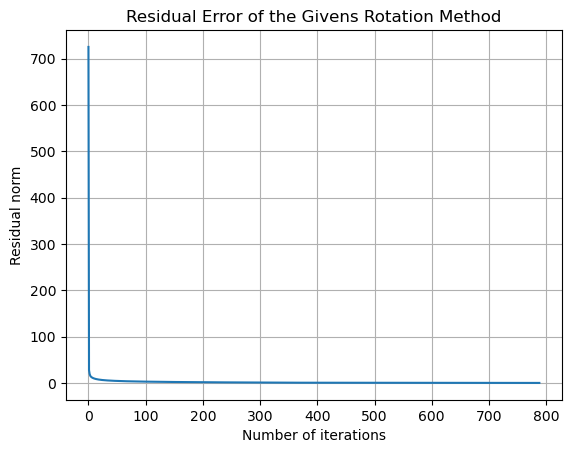

In [24]:
plt.plot(Lresiduals)
plt.grid()
plt.xlabel('Number of iterations')
plt.ylabel('Residual norm')
#plt.yscale("log")
plt.title("Residual Error of the Givens Rotation Method")
#plt.savefig("GrotGMRESlarge.pdf", format = 'pdf')
plt.show()